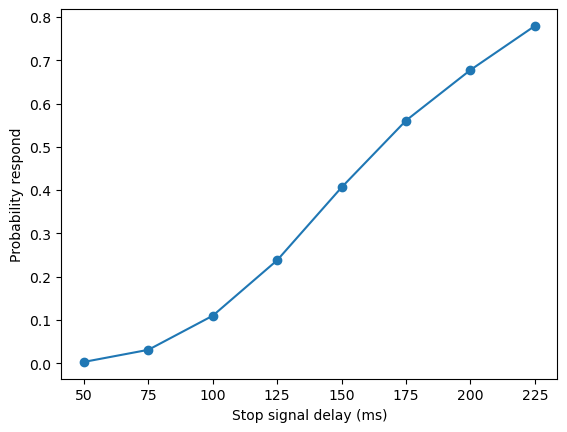

In [1]:
# -*- coding: utf-8 -*-
"""
Example code for a race model for countermanding saccade task

Reference:
Boucher, Leanne, et al.
"Inhibitory control in mind and brain: an interactive race model of countermanding saccades."
Psychological review 114.2 (2007): 376.

@author: Guangyu Robert Yang, 2017/04
"""
from __future__ import division

import warnings
import numpy as np
import matplotlib.pyplot as plt

def run_race(params, n_trial=1, dt=1., max_t=500, rng=None):
    '''
    Run race model
    '''

    # Parameters
    p = params

    # Number of time point
    n_t = int(max_t/dt)
    
    # Random number generator
    if rng is None:
        rng = np.random.RandomState()

    # Initialization
    go      = np.zeros(n_trial)
    stop    = np.zeros(n_trial)
    notcross = np.ones(n_trial, dtype=bool)

    # Storage
    rts  = np.ones(n_trial) * max_t
    gos  = np.zeros(n_trial)

    for i_t in range(n_t):
        # Update decision variable
        dgo = dt/p['tau']*(p['mu_go']-p['k']*go-p['beta_stop']*stop) + \
              np.sqrt(dt/p['tau'])*p['sigma_go']*rng.randn(n_trial)

        if i_t*dt > p['SSD']:
            dstop = dt/p['tau']*(p['mu_stop']-p['k']*stop-p['beta_go']*go) + \
                    np.sqrt(dt/p['tau'])*p['sigma_stop']*rng.randn(n_trial)
        else:
            dstop = 0
        go   += dgo
        stop += dstop

        # Go crossing threshold
        cross_go = np.logical_and(go>p['threshold'], notcross)
        gos[cross_go] = 1
        rts[cross_go] = i_t*dt

        # Crossing lower boundary
        cross_stop = np.logical_and(stop>p['threshold'], notcross)
        gos[cross_stop] = 0
        rts[cross_stop] = i_t*dt

        # Update crossing status
        notcross[cross_go]   = False
        notcross[cross_stop] = False

    # If at the end, there are still decision variables not crossed
    if np.any(notcross):
        warnings.warn('Maximum time {:0.2f}s is likely too short'.format(max_t))

        gos[np.logical_and(go>=stop, notcross)] = 1
        gos[np.logical_and(go< stop, notcross)] = 0

    # Store results and run simple analysis
    result = {'gos'    : gos,
              'rts'     : rts,
              'rt_mean' : np.mean(rts),
              'pgo'     : np.sum(gos==1)/n_trial}

    return result


# Setting parameters
n_trial  = 5000

# Parameters from fit for Monkey A independent race model (Boucher 2007)
params = dict(
    tau         = 1,
    k           = 0, # Leakage
    threshold   = 1000, # response threshold
    mu_go       = 5.09,
    sigma_go    = 26.38,
    mu_stop     = 50.24,
    sigma_stop  = 40.17,
    beta_go     = 0., # independent race
    beta_stop   = 0., # independent race
    SSD         = 0,  # Stop-signal delay
)

# Stop signal delays
SSDs = range(50, 250, 25)

# Storage
rt_means = list()
pgos     = list()

for SSD in SSDs:
    params['SSD'] = SSD
    result = run_race(params, n_trial=n_trial, dt=params['tau'])
    rt_means.append(result['rt_mean'])
    pgos.append(result['pgo'])

# Plotting results
plt.figure()
plt.plot(SSDs, pgos, 'o-')
plt.xlabel('Stop signal delay (ms)')
plt.ylabel('Probability respond')
plt.savefig('boucher2007_racemodel.pdf')
plt.show()